# Foursquare Dataset (Coffee shops) (New)

In [167]:
import pandas as pd 

In [169]:
df = pd.read_csv("fullcoffeeshpos_with_google_status_UPDATED.csv")

In [171]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      2410 non-null   object 
 1   Name             2410 non-null   object 
 2   Latitude         2410 non-null   float64
 3   Longitude        2410 non-null   float64
 4   Category         2410 non-null   object 
 5   Rating           2410 non-null   object 
 6   Popularity       2410 non-null   float64
 7   Google Place ID  1070 non-null   object 
 8   Business Status  2410 non-null   object 
 9   Distance (m)     2339 non-null   float64
dtypes: float64(4), object(6)
memory usage: 188.4+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
0,57c6ebaf498e35841d656d24,coffee valley (وادي القهوة),26.250352,50.202656,Coffee Shop,8.5,0.983517,NaN,NOT FOUND,8247.075668
1,4f93faafe4b015eb3e04e556,al-kharj international coffee house (مقهى الخر...,26.260022,50.197641,Coffee Shop,No rating,0.932691,NaN,NOT FOUND,366136.199555
2,62c4a4963e2a294ed8a25d2f,espresso station (اسبريسو ستيشن),26.241778,50.214466,Coffee Shop,8.8,0.968299,ChIJAdfdZe3DST4RZa6OMkKHAik,OPERATIONAL,22.548395
3,5f6e3c929227c33c89239843,cesario coffee,26.255965,50.220532,Coffee Shop,8.6,0.991283,ChIJL8UsA0DDST4RYNisFSUqTgA,OPERATIONAL,61.034601
4,5f41fd2c99f7251476c30e9c,sun room cafe & restaurant,26.255705,50.220895,Café,6.2,0.290227,NaN,NOT FOUND,1821.939163


## Check Business Status

In [174]:
#Check business status counts
status_counts_df = df['Business Status'].value_counts().reset_index()
status_counts_df.columns = ['Business Status', 'Count']
print(status_counts_df)

      Business Status  Count
0           NOT FOUND   1340
1         OPERATIONAL    762
2  CLOSED_PERMANENTLY    252
3  CLOSED_TEMPORARILY     55
4             UNKNOWN      1


In [165]:
df.loc[df['Business ID'] == '508823f0498ef4b8c006c651']
#df.loc[df['Google Place ID'] == 'ChIJ8y4Q9LrdST4RiQ1G8GIOXWs']



,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
1366,508823f0498ef4b8c006c651,كافيه ليوان,26.401084,50.051615,Café,7.4,0.91664,ChIJUWGPzxn9ST4RNYw3jyAHZfI,CLOSED_PERMANENTLY,10.034446


In [176]:
#Manual Updates: 
df.loc[df['Business ID'] == '5e26c9bbae47d70007e62a02', 'Business Status'] = 'CLOSED_PERMANENTLY'
df.loc[df['Business ID'] == '5f2d9947d4f69d667de7b4c5', 'Business Status'] = 'CLOSED_PERMANENTLY'
df.loc[df['Business ID'] == '600ad9e38653f7304a4126ef', 'Business Status'] = 'CLOSED_PERMANENTLY'
#df.loc[df['Business ID'] == '5cb1d4b765cdf8002bbf6ead', 'Business Status'] = 'CLOSED_PERMANENTLY'
df.loc[df['Business ID'] == '5d238d9b6d22da0023bb1c6a', 'Business Status'] = 'CLOSED_PERMANENTLY'
df.loc[df['Business ID'] == '61d6e5c2589c5063e6672c19', 'Business Status'] = 'OPERATIONAL'


#Manual Removal for businesses not found or out of scope
drop_business_byBusinessID = [
    '4edcf5d661af8a14b95c3161',
    'ChIJW1UlutnnST4Rc3r_kCnf1gQ',
    '5b3ce9e52b274a002c0b3ac7',
    '5dbcbdea2847c500087446d4',
    '50ca2277e4b0d68fddc9e4d4',
    '5c683c09d48ec10039195977',
    '635d5f707ff1a87e364770b6',
    '5f35c149786a7936f7129c10',
    '62753c2ac2391d5e9d52694d',
    '6085df6e91cfad76f1b0291c',
    '5436ca22498ef0ff09519f47',
    '63fdb86963a8546ec2a51537',
    '51540a1de4b00a630f9aadbe',
    '5749e794498e18ae9e62a95d',
    
]

drop_business_byGoogleID = [
    'ChIJk8B4KQb_ST4RQyu9nnW21lQ',
    'ChIJKyYA-Fn_ST4R7MkYlB5qEGM',
    'ChIJSQb4XM3_ST4Rxvggnz4K83g',
]


df = df[~df['Business ID'].isin(drop_business_byBusinessID)]
df = df[~df['Google Place ID'].isin(drop_business_byGoogleID)]


In [178]:
#Check business status counts
status_counts_df = df['Business Status'].value_counts().reset_index()
status_counts_df.columns = ['Business Status', 'Count']
print(status_counts_df)

      Business Status  Count
0           NOT FOUND   1331
1         OPERATIONAL    751
2  CLOSED_PERMANENTLY    253
3  CLOSED_TEMPORARILY     55
4             UNKNOWN      1


In [180]:
#Drop closed and not found businesses
df_operational = df[~df['Business Status'].isin(['CLOSED_PERMANENTLY', 'CLOSED_TEMPORARILY','NOT FOUND', 'UNKNOWN'])]
df_operational

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
2,62c4a4963e2a294ed8a25d2f,espresso station (اسبريسو ستيشن),26.241778,50.214466,Coffee Shop,8.8,0.968299,ChIJAdfdZe3DST4RZa6OMkKHAik,OPERATIONAL,22.548395
3,5f6e3c929227c33c89239843,cesario coffee,26.255965,50.220532,Coffee Shop,8.6,0.991283,ChIJL8UsA0DDST4RYNisFSUqTgA,OPERATIONAL,61.034601
8,5f97ed2d107f3c6dc6c1a5aa,blue sky,26.254914,50.214438,Coffee Shop,No rating,0.963778,ChIJA1rVWjjDST4RcKfC6nIvWlY,OPERATIONAL,45.840860
20,6032ae77fe87f20035e807ae,al-taam coffee and flour mill (مطاحن وبن التام),26.273722,50.185155,Café,No rating,0.943726,ChIJp_j-xQfoST4RsVjm_vbAVNY,OPERATIONAL,13.973567
23,58133f0638fae1f20d72985a,شاي جمر,26.274829,50.185198,Tea Room,7.6,0.992660,ChIJeRI7hn3pST4RUOGbnAnpSJ0,OPERATIONAL,54.355222
24,5cae56c1911fc4002c178ee6,deawaniyat gdoe (ديوانية قدوع),26.269075,50.190190,Coffee Shop,No rating,0.544394,ChIJ61O7sAPoST4RDa2oMwn0MRw,OPERATIONAL,49.435134
29,63fe4920a7b0730de255d38f,اوراق الشاي الفاخرة,26.274264,50.184789,Tea Room,No rating,0.957353,ChIJeRI7hn3pST4RUOGbnAnpSJ0,OPERATIONAL,20.492371
36,5dd5672fc61ceb00088c19b5,shathrat cafe (شذرات كافيه),26.275161,50.218922,Café,9.0,0.971869,ChIJLTCzdZfDST4RohG5zSQwU4s,OPERATIONAL,25.974410
38,5789215e498e67265b7749be,tea time,26.277549,50.211453,Coffee Shop,8.5,0.975564,ChIJ8ZznkLTpST4RgZaPELwGnmk,OPERATIONAL,21.675713
39,4ef0e9a99a52cecf43832c2b,sea rock (صخر البحر),26.261907,50.219034,Café,8.0,0.936950,ChIJufwGto7CST4Recm5GojTovM,OPERATIONAL,52.634279


## Check Duplicates

In [182]:
# Check for duplicates in the 'ColumnName'
duplicates = df_operational[df_operational.duplicated(subset=['Google Place ID'], keep=False)]

pd.set_option('display.max_rows', None)
duplicates.info()
# Display duplicates
duplicates


<class 'pandas.core.frame.DataFrame'>
Index: 109 entries, 23 to 2401
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      109 non-null    object 
 1   Name             109 non-null    object 
 2   Latitude         109 non-null    float64
 3   Longitude        109 non-null    float64
 4   Category         109 non-null    object 
 5   Rating           109 non-null    object 
 6   Popularity       109 non-null    float64
 7   Google Place ID  109 non-null    object 
 8   Business Status  109 non-null    object 
 9   Distance (m)     109 non-null    float64
dtypes: float64(4), object(6)
memory usage: 9.4+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
23,58133f0638fae1f20d72985a,شاي جمر,26.274829,50.185198,Tea Room,7.6,0.992660,ChIJeRI7hn3pST4RUOGbnAnpSJ0,OPERATIONAL,54.355222
29,63fe4920a7b0730de255d38f,اوراق الشاي الفاخرة,26.274264,50.184789,Tea Room,No rating,0.957353,ChIJeRI7hn3pST4RUOGbnAnpSJ0,OPERATIONAL,20.492371
87,58cd174c297c16730ce8c3e9,7 grams (٧ جرام),26.290708,50.180910,Coffee Shop,8.6,0.993174,ChIJLzHtU9jnST4RZ6qxdfdGdRs,OPERATIONAL,60.999699
99,4c0404379a7920a166acd079,costa coffee (كوستا كوفي),26.290199,50.181232,Coffee Shop,7.0,0.941609,ChIJ7Z7cVbXnST4R0aQnUy3UzKU,OPERATIONAL,48.157233
107,53d90cf8498ed408f28d2224,al-rashid avenue coffee & bar,26.288802,50.179758,Café,No rating,0.866021,ChIJ7Z7cVbXnST4R0aQnUy3UzKU,OPERATIONAL,168.553302
318,53a86cca498e11062f6db2d5,cinnabon dh-mall,26.304769,50.170603,Café,No rating,0.950226,ChIJbRZUSjDmST4R-O7kAWRJ7yk,OPERATIONAL,174.612226
319,53f7742c498e240441b63550,cinabon | dhahran mall,26.305138,50.170979,Café,No rating,0.904974,ChIJbRZUSjDmST4R-O7kAWRJ7yk,OPERATIONAL,128.580566
400,63038bfa51da3a7bfbd244d6,tim hortons,26.321822,50.021235,Coffee Shop,8.0,0.775708,ChIJy3un-QzjST4RdWmgRDcDoMw,OPERATIONAL,106.301570
401,6326b135141f9444f091a93a,tim hortons - kfmmc,26.320817,50.021526,Café,7.9,0.999655,ChIJy3un-QzjST4RdWmgRDcDoMw,OPERATIONAL,9.711548
430,5cbb33f0531593002c7e40f0,spark coffee drive thru,26.332617,50.161098,Coffee Shop,8.4,0.994777,ChIJrftVrCLnST4R29_0CS_2HtQ,OPERATIONAL,37.246584


In [184]:
#sort based google place id to display the same business with different names in the same area 
duplicates = duplicates.sort_values(by='Google Place ID')
duplicates

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
839,62fa7cf7cd4b184a5584bc2e,ratio speciality coffee (ريشيو للقهوة المختصة),26.362719,50.198088,Coffee Shop,9.0,0.995128,ChIJ-SntR8zvST4RwyIzibraf5w,OPERATIONAL,29.142400
861,62fe5633cc4dee5a7cbb16ab,ريشيو,26.362548,50.198156,Coffee Shop,No rating,0.174722,ChIJ-SntR8zvST4RwyIzibraf5w,OPERATIONAL,10.204350
1139,63e657d61fda9c16c7cefb67,٧ جرام,26.391740,50.036930,Café,No rating,0.885033,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,171.753718
1143,63e6613adc99b7030b7e29ba,٧ جرام,26.389911,50.037195,Café,No rating,0.865063,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,33.476544
1144,634fb3c9480c1a5acc9aea1f,7 grams (brewign soon),26.390169,50.037335,Coffee Shop,No rating,0.671415,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,12.286213
1121,634fb5f0efd08b479094c673,7 grams,26.390513,50.037291,Coffee Shop,8.0,0.971416,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,34.038718
1812,63fc7229e7e81b0b49ca5b9e,cup of karak,26.462324,50.049516,Café,No rating,0.101072,ChIJ1_Ab2SD_ST4R-aRFKAAcbxo,OPERATIONAL,20.382450
1811,64172b56309c0779db25b8d7,گلاص كرك,26.462338,50.049472,Café,No rating,0.949678,ChIJ1_Ab2SD_ST4R-aRFKAAcbxo,OPERATIONAL,22.745656
1501,626d98caf6d00453fabd730c,hokm,26.406324,50.186832,Coffee Shop,No rating,0.998970,ChIJ1wAXYgDvST4R5VWfYyPIblM,OPERATIONAL,29.298734
1503,627bf84c691d2104227e496a,hokm cafe مقهى حُكم,26.406018,50.186901,Café,No rating,0.073139,ChIJ1wAXYgDvST4R5VWfYyPIblM,OPERATIONAL,53.060484


### Map Visualization of Duplicates

   Cluster  Number of Points
0       -1                23
1        0                19
2        4                14
3        6                12
4        2                11
5        1                10
6        3                 8
7        5                 6
8        7                 6


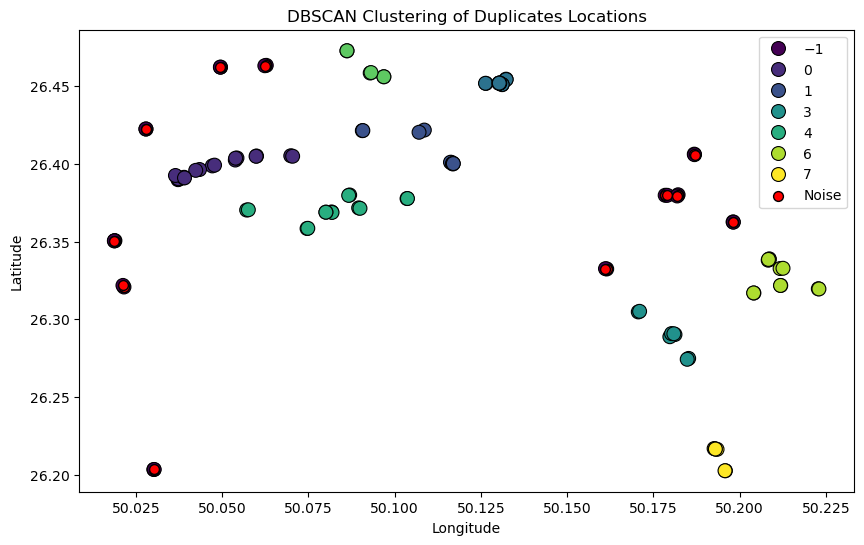

In [186]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.cluster import DBSCAN

# Apply DBSCAN Clustering
dbscan = DBSCAN(eps=0.022, min_samples=5)  #eps was determined based on the 2nd derivative # eps defines the neighborhood size, min_samples defines cluster density
duplicates['Cluster'] = dbscan.fit_predict(duplicates[['Latitude', 'Longitude']])

# Plot DBSCAN Clustering Results
plt.figure(figsize=(10, 6))
sns.scatterplot(x=duplicates['Longitude'], y=duplicates['Latitude'], hue=duplicates['Cluster'], palette='viridis', s=100, edgecolor='k')

# Highlight noise points (-1) separately
noise = duplicates[duplicates['Cluster'] == -1]
plt.scatter(noise['Longitude'], noise['Latitude'], color='red', label='Noise', s=50, edgecolors='black')

# Count the number of points in each cluster
cluster_counts = duplicates['Cluster'].value_counts().reset_index()
cluster_counts.columns = ['Cluster', 'Number of Points']

# Display the count of neighbors per cluster
print(cluster_counts)

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("DBSCAN Clustering of Duplicates Locations")
plt.legend()
plt.show()

In [188]:
cluster_0 = duplicates[duplicates['Cluster'] == -1]
cluster_0.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23 entries, 839 to 400
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      23 non-null     object 
 1   Name             23 non-null     object 
 2   Latitude         23 non-null     float64
 3   Longitude        23 non-null     float64
 4   Category         23 non-null     object 
 5   Rating           23 non-null     object 
 6   Popularity       23 non-null     float64
 7   Google Place ID  23 non-null     object 
 8   Business Status  23 non-null     object 
 9   Distance (m)     23 non-null     float64
 10  Cluster          23 non-null     int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 2.2+ KB


In [190]:
import folium
# Define the map centered around the average location
map_center = [cluster_0['Latitude'].mean(), cluster_0['Longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=12)

# Assign a color to each cluster
cluster_colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'purple', 4: 'orange'}

# Add markers for each business
for _, row in cluster_0.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Name: {row['Name']}\nPopularity:{row['Popularity']},\nFoursquareID: {row['Business ID']}\nGoogleMapsID: {row['Google Place ID']}\nlat: {row['Latitude']}\nlong:{row['Longitude']}",
        tooltip=f"Name: {row['Name']}",
        icon=folium.Icon(color=cluster_colors.get(row['Cluster'], 'gray'))
    ).add_to(m)

# Display the map
m

m.save("coffee_maps.html")

In [149]:
#duplicates[duplicates['Google Place ID']=='ChIJW1UlutnnST4Rc3r_kCnf1gQ']
df[df['Business ID']=='5436ca22498ef0ff09519f47']

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m)
1796,5436ca22498ef0ff09519f47,delle rose (café & restaurant),26.472966,50.04842,Café,7.9,0.96097,ChIJsaiVYWj-ST4RHMDQ9eqjRdI,OPERATIONAL,15.29584


In [194]:
#manual removal for business that are not duplicates
not_dup_removeBy_GoogleID = [
    'ChIJVYliKUT9ST4R1-jHDxLxGUQ',
    
    
]

not_dup_removeBy_BusinessID = [
    
]
#duplicates = duplicates[~duplicates['Business ID'].isin(not_dup_removeBy_BusinessID)]
duplicates = duplicates[~duplicates['Google Place ID'].isin(not_dup_removeBy_GoogleID)]

duplicates.info()

<class 'pandas.core.frame.DataFrame'>
Index: 107 entries, 839 to 812
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      107 non-null    object 
 1   Name             107 non-null    object 
 2   Latitude         107 non-null    float64
 3   Longitude        107 non-null    float64
 4   Category         107 non-null    object 
 5   Rating           107 non-null    object 
 6   Popularity       107 non-null    float64
 7   Google Place ID  107 non-null    object 
 8   Business Status  107 non-null    object 
 9   Distance (m)     107 non-null    float64
 10  Cluster          107 non-null    int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 10.0+ KB


In [196]:
duplicates

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
839,62fa7cf7cd4b184a5584bc2e,ratio speciality coffee (ريشيو للقهوة المختصة),26.362719,50.198088,Coffee Shop,9.0,0.995128,ChIJ-SntR8zvST4RwyIzibraf5w,OPERATIONAL,29.142400,-1
861,62fe5633cc4dee5a7cbb16ab,ريشيو,26.362548,50.198156,Coffee Shop,No rating,0.174722,ChIJ-SntR8zvST4RwyIzibraf5w,OPERATIONAL,10.204350,-1
1139,63e657d61fda9c16c7cefb67,٧ جرام,26.391740,50.036930,Café,No rating,0.885033,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,171.753718,0
1143,63e6613adc99b7030b7e29ba,٧ جرام,26.389911,50.037195,Café,No rating,0.865063,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,33.476544,0
1144,634fb3c9480c1a5acc9aea1f,7 grams (brewign soon),26.390169,50.037335,Coffee Shop,No rating,0.671415,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,12.286213,0
1121,634fb5f0efd08b479094c673,7 grams,26.390513,50.037291,Coffee Shop,8.0,0.971416,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,34.038718,0
1812,63fc7229e7e81b0b49ca5b9e,cup of karak,26.462324,50.049516,Café,No rating,0.101072,ChIJ1_Ab2SD_ST4R-aRFKAAcbxo,OPERATIONAL,20.382450,-1
1811,64172b56309c0779db25b8d7,گلاص كرك,26.462338,50.049472,Café,No rating,0.949678,ChIJ1_Ab2SD_ST4R-aRFKAAcbxo,OPERATIONAL,22.745656,-1
1501,626d98caf6d00453fabd730c,hokm,26.406324,50.186832,Coffee Shop,No rating,0.998970,ChIJ1wAXYgDvST4R5VWfYyPIblM,OPERATIONAL,29.298734,-1
1503,627bf84c691d2104227e496a,hokm cafe مقهى حُكم,26.406018,50.186901,Café,No rating,0.073139,ChIJ1wAXYgDvST4R5VWfYyPIblM,OPERATIONAL,53.060484,-1


In [198]:
# find the max popularity using groupby()

# Find the max popularity per Place ID and store the best record
df_max_popularity = duplicates.loc[duplicates.groupby('Google Place ID')['Popularity'].idxmax()]

# Reset index for clarity
#df_max_popularity = df_max_popularity.reset_index(drop=True)

df_max_popularity.info()
df_max_popularity



<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, 839 to 805
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      51 non-null     object 
 1   Name             51 non-null     object 
 2   Latitude         51 non-null     float64
 3   Longitude        51 non-null     float64
 4   Category         51 non-null     object 
 5   Rating           51 non-null     object 
 6   Popularity       51 non-null     float64
 7   Google Place ID  51 non-null     object 
 8   Business Status  51 non-null     object 
 9   Distance (m)     51 non-null     float64
 10  Cluster          51 non-null     int64  
dtypes: float64(4), int64(1), object(6)
memory usage: 4.8+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
839,62fa7cf7cd4b184a5584bc2e,ratio speciality coffee (ريشيو للقهوة المختصة),26.362719,50.198088,Coffee Shop,9.0,0.995128,ChIJ-SntR8zvST4RwyIzibraf5w,OPERATIONAL,29.142400,-1
1121,634fb5f0efd08b479094c673,7 grams,26.390513,50.037291,Coffee Shop,8.0,0.971416,ChIJ0yLJyfP9ST4RNOksnykUNZE,OPERATIONAL,34.038718,0
1811,64172b56309c0779db25b8d7,گلاص كرك,26.462338,50.049472,Café,No rating,0.949678,ChIJ1_Ab2SD_ST4R-aRFKAAcbxo,OPERATIONAL,22.745656,-1
1501,626d98caf6d00453fabd730c,hokm,26.406324,50.186832,Coffee Shop,No rating,0.998970,ChIJ1wAXYgDvST4R5VWfYyPIblM,OPERATIONAL,29.298734,-1
748,6292fb5c69677a49d1e8832e,dunkin’ donuts drive-through,26.350529,50.018764,Coffee Shop,8.5,0.999907,ChIJ4-iJs73jST4RSKm2NI6uCK8,OPERATIONAL,9.443560,-1
1189,5f3a1a272eb19c2fbfb6ec3d,frieze cafe (فريز كافيه),26.404999,50.070413,Coffee Shop,8.8,0.987453,ChIJ41H4zfr9ST4RA8vtdQpy0TQ,OPERATIONAL,44.483435,0
1480,56070210498ee0fbd77398d0,كيك وكرك,26.401111,50.116172,Café,No rating,0.947170,ChIJ57_nYEv7ST4R81PavKhGsI8,OPERATIONAL,45.568138,1
1769,61ddba69c31e9316c2474cc3,crepele cafe,26.454597,50.132271,Café,No rating,0.962233,ChIJ6TIHD-D7ST4RMU5Yud1MO_k,OPERATIONAL,10.601224,2
99,4c0404379a7920a166acd079,costa coffee (كوستا كوفي),26.290199,50.181232,Coffee Shop,7.0,0.941609,ChIJ7Z7cVbXnST4R0aQnUy3UzKU,OPERATIONAL,48.157233,3
1045,5793970d498ee25368a57980,4squares cafe (مقهى الأربعة مربعات),26.379854,50.178398,Café,8.1,0.977348,ChIJ7aW39oHlST4Rbg6NmVWpYEM,OPERATIONAL,21.121671,-1


In [200]:
df_max_popularity[df_max_popularity.duplicated(subset=['Google Place ID'], keep=False)]

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster


## Checking df_operational excluding duplicates dataframe

In [202]:
# Subtract df_subset from df_main (remove matching rows)
df_result = df_operational.merge(duplicates, how='left', indicator=True).query('_merge == "left_only"').drop(columns=['_merge'])
df_result.info()


<class 'pandas.core.frame.DataFrame'>
Index: 644 entries, 0 to 749
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      644 non-null    object 
 1   Name             644 non-null    object 
 2   Latitude         644 non-null    float64
 3   Longitude        644 non-null    float64
 4   Category         644 non-null    object 
 5   Rating           644 non-null    object 
 6   Popularity       644 non-null    float64
 7   Google Place ID  643 non-null    object 
 8   Business Status  644 non-null    object 
 9   Distance (m)     644 non-null    float64
 10  Cluster          0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 60.4+ KB


In [204]:
df_result

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
0,62c4a4963e2a294ed8a25d2f,espresso station (اسبريسو ستيشن),26.241778,50.214466,Coffee Shop,8.8,0.968299,ChIJAdfdZe3DST4RZa6OMkKHAik,OPERATIONAL,22.548395,NaN
1,5f6e3c929227c33c89239843,cesario coffee,26.255965,50.220532,Coffee Shop,8.6,0.991283,ChIJL8UsA0DDST4RYNisFSUqTgA,OPERATIONAL,61.034601,NaN
2,5f97ed2d107f3c6dc6c1a5aa,blue sky,26.254914,50.214438,Coffee Shop,No rating,0.963778,ChIJA1rVWjjDST4RcKfC6nIvWlY,OPERATIONAL,45.840860,NaN
3,6032ae77fe87f20035e807ae,al-taam coffee and flour mill (مطاحن وبن التام),26.273722,50.185155,Café,No rating,0.943726,ChIJp_j-xQfoST4RsVjm_vbAVNY,OPERATIONAL,13.973567,NaN
5,5cae56c1911fc4002c178ee6,deawaniyat gdoe (ديوانية قدوع),26.269075,50.190190,Coffee Shop,No rating,0.544394,ChIJ61O7sAPoST4RDa2oMwn0MRw,OPERATIONAL,49.435134,NaN
7,5dd5672fc61ceb00088c19b5,shathrat cafe (شذرات كافيه),26.275161,50.218922,Café,9.0,0.971869,ChIJLTCzdZfDST4RohG5zSQwU4s,OPERATIONAL,25.974410,NaN
8,5789215e498e67265b7749be,tea time,26.277549,50.211453,Coffee Shop,8.5,0.975564,ChIJ8ZznkLTpST4RgZaPELwGnmk,OPERATIONAL,21.675713,NaN
9,4ef0e9a99a52cecf43832c2b,sea rock (صخر البحر),26.261907,50.219034,Café,8.0,0.936950,ChIJufwGto7CST4Recm5GojTovM,OPERATIONAL,52.634279,NaN
10,59089ae95d891b37234c78cb,sunroom cafe and restaurant,26.271953,50.221238,Café,7.6,0.977468,ChIJ13byMYHCST4RDO9g0pDdu-o,OPERATIONAL,22.399034,NaN
11,523d43c4498e8150c147db1e,azeem cafeteria,26.277812,50.213213,Tea Room,6.3,0.923435,ChIJt5VBPiboST4RNG3kU9cjcrs,OPERATIONAL,27.098420,NaN


In [226]:
df_result[df_result['Business ID'] == '62d9270bec695a20a37c7723']

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
654,62d9270bec695a20a37c7723,إيحاء,26.481184,50.046556,Coffee Shop,No rating,0.970805,ChIJ-XIlAI__ST4Ruu6RfSrZqlw,OPERATIONAL,5.455086,NaN


In [228]:
#Clean df_result from non-food businesses/ retaurants/ or does not exist
not_business_removeBy_BusinessID = [
    '6186f490037e414d9645dcbb',
    '5648066438fac549468e4a0b',
    '4dc516e0c65b89d3ca64cefe',
    '62d9270bec695a20a37c7723',
    '5a4fcc03bb8d36452d23b77b',
    '4dd2d60bd4c01eb457dbb2fb',
    '5a4fcc03bb8d36452d23b77b',
    
]

df_result = df_result[~df_result['Business ID'].isin(not_business_removeBy_BusinessID)]
df_result.info()

<class 'pandas.core.frame.DataFrame'>
Index: 638 entries, 0 to 749
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      638 non-null    object 
 1   Name             638 non-null    object 
 2   Latitude         638 non-null    float64
 3   Longitude        638 non-null    float64
 4   Category         638 non-null    object 
 5   Rating           638 non-null    object 
 6   Popularity       638 non-null    float64
 7   Google Place ID  637 non-null    object 
 8   Business Status  638 non-null    object 
 9   Distance (m)     638 non-null    float64
 10  Cluster          0 non-null      float64
dtypes: float64(5), object(6)
memory usage: 59.8+ KB


## Final Dataset (df_result + max popularity from duplicated rows )

In [230]:
# Concatenate along rows (axis=0)

df_cafe = pd.concat([df_result, df_max_popularity], ignore_index=True)

df_cafe.info()
df_cafe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Business ID      689 non-null    object 
 1   Name             689 non-null    object 
 2   Latitude         689 non-null    float64
 3   Longitude        689 non-null    float64
 4   Category         689 non-null    object 
 5   Rating           689 non-null    object 
 6   Popularity       689 non-null    float64
 7   Google Place ID  688 non-null    object 
 8   Business Status  689 non-null    object 
 9   Distance (m)     689 non-null    float64
 10  Cluster          51 non-null     float64
dtypes: float64(5), object(6)
memory usage: 59.3+ KB


,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
0,62c4a4963e2a294ed8a25d2f,espresso station (اسبريسو ستيشن),26.241778,50.214466,Coffee Shop,8.8,0.968299,ChIJAdfdZe3DST4RZa6OMkKHAik,OPERATIONAL,22.548395,NaN
1,5f6e3c929227c33c89239843,cesario coffee,26.255965,50.220532,Coffee Shop,8.6,0.991283,ChIJL8UsA0DDST4RYNisFSUqTgA,OPERATIONAL,61.034601,NaN
2,5f97ed2d107f3c6dc6c1a5aa,blue sky,26.254914,50.214438,Coffee Shop,No rating,0.963778,ChIJA1rVWjjDST4RcKfC6nIvWlY,OPERATIONAL,45.840860,NaN
3,6032ae77fe87f20035e807ae,al-taam coffee and flour mill (مطاحن وبن التام),26.273722,50.185155,Café,No rating,0.943726,ChIJp_j-xQfoST4RsVjm_vbAVNY,OPERATIONAL,13.973567,NaN
4,5cae56c1911fc4002c178ee6,deawaniyat gdoe (ديوانية قدوع),26.269075,50.190190,Coffee Shop,No rating,0.544394,ChIJ61O7sAPoST4RDa2oMwn0MRw,OPERATIONAL,49.435134,NaN
5,5dd5672fc61ceb00088c19b5,shathrat cafe (شذرات كافيه),26.275161,50.218922,Café,9.0,0.971869,ChIJLTCzdZfDST4RohG5zSQwU4s,OPERATIONAL,25.974410,NaN
6,5789215e498e67265b7749be,tea time,26.277549,50.211453,Coffee Shop,8.5,0.975564,ChIJ8ZznkLTpST4RgZaPELwGnmk,OPERATIONAL,21.675713,NaN
7,4ef0e9a99a52cecf43832c2b,sea rock (صخر البحر),26.261907,50.219034,Café,8.0,0.936950,ChIJufwGto7CST4Recm5GojTovM,OPERATIONAL,52.634279,NaN
8,59089ae95d891b37234c78cb,sunroom cafe and restaurant,26.271953,50.221238,Café,7.6,0.977468,ChIJ13byMYHCST4RDO9g0pDdu-o,OPERATIONAL,22.399034,NaN
9,523d43c4498e8150c147db1e,azeem cafeteria,26.277812,50.213213,Tea Room,6.3,0.923435,ChIJt5VBPiboST4RNG3kU9cjcrs,OPERATIONAL,27.098420,NaN


In [236]:
print("Total number of coffee shops = ", len(df_cafe))

Total number of coffee shops =  689


In [238]:
df_cafe['Category'] = 'Coffee Shop'
df_cafe.head()

,Business ID,Name,Latitude,Longitude,Category,Rating,Popularity,Google Place ID,Business Status,Distance (m),Cluster
0,62c4a4963e2a294ed8a25d2f,espresso station (اسبريسو ستيشن),26.241778,50.214466,Coffee Shop,8.8,0.968299,ChIJAdfdZe3DST4RZa6OMkKHAik,OPERATIONAL,22.548395,NaN
1,5f6e3c929227c33c89239843,cesario coffee,26.255965,50.220532,Coffee Shop,8.6,0.991283,ChIJL8UsA0DDST4RYNisFSUqTgA,OPERATIONAL,61.034601,NaN
2,5f97ed2d107f3c6dc6c1a5aa,blue sky,26.254914,50.214438,Coffee Shop,No rating,0.963778,ChIJA1rVWjjDST4RcKfC6nIvWlY,OPERATIONAL,45.840860,NaN
3,6032ae77fe87f20035e807ae,al-taam coffee and flour mill (مطاحن وبن التام),26.273722,50.185155,Coffee Shop,No rating,0.943726,ChIJp_j-xQfoST4RsVjm_vbAVNY,OPERATIONAL,13.973567,NaN
4,5cae56c1911fc4002c178ee6,deawaniyat gdoe (ديوانية قدوع),26.269075,50.190190,Coffee Shop,No rating,0.544394,ChIJ61O7sAPoST4RDa2oMwn0MRw,OPERATIONAL,49.435134,NaN


In [240]:
df_cafe.to_csv("final_coffeeshops_dataset_cleaned.csv", index=False, encoding="utf-8-sig")